--- Large Dataset 'student_performance_data.csv' (1,000 rows) Saved Successfully ---

=== 1. DATA AUDIT & CLEANING CHECKS ===
Dataset Shape: (1000, 7)

Missing Values Check:
 student_id               0
study_hours_per_week     0
attendance_percentage    0
previous_exam_score      0
extracurricular_hours    0
sleep_hours              0
final_result             0
dtype: int64

Duplicate Rows Check: 0

Dataset Summary Statistics:
        study_hours_per_week  attendance_percentage  previous_exam_score  \
count               1000.00                1000.00              1000.00   
mean                  18.18                  72.89                67.56   
std                    9.64                  16.07                18.38   
min                    2.20                  45.20                35.00   
25%                    9.78                  58.28                51.75   
50%                   18.40                  73.50                68.00   
75%                   26.60                

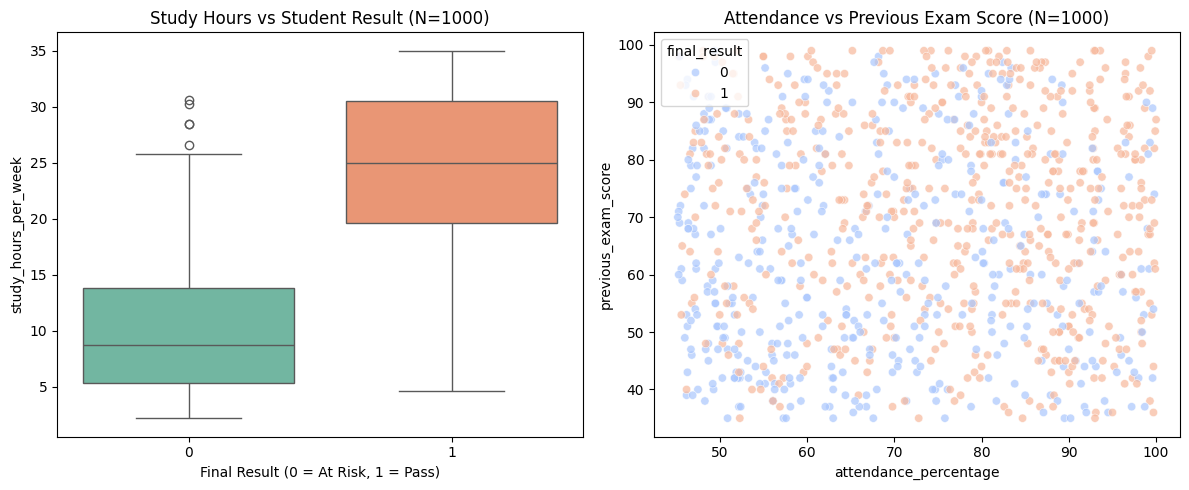


=== 2. MODEL EVALUATION RESULTS ===
Training Set Size : 800 samples
Test Set Size     : 200 samples (Substantial Evaluation Base)
Random Forest Accuracy: 89.50%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

 At Risk (0)       0.88      0.87      0.88        87
    Pass (1)       0.90      0.91      0.91       113

    accuracy                           0.90       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.90      0.89       200



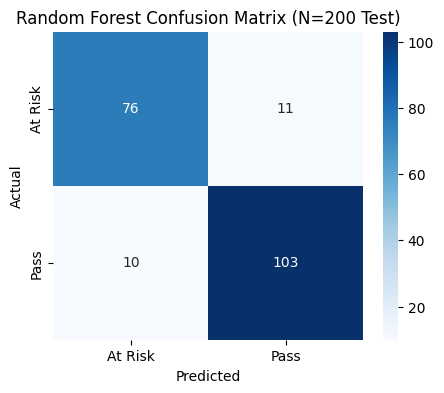


=== 3. SAMPLE STUDENT PREDICTION ===
Input Features: {'study_hours_per_week': 7.3, 'attendance_percentage': 57.3, 'previous_exam_score': 35, 'extracurricular_hours': 9, 'sleep_hours': 9}
Predicted Result : AT RISK (0)
Confidence Level : 97.15%


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. EXPANDED REALISTIC DATASET CREATION (1,000 SAMPLES)
# ---------------------------------------------------------
np.random.seed(42)
n_students = 1000

data = {
    'student_id': [f'STD_{1000 + i}' for i in range(n_students)],
    'study_hours_per_week': np.round(np.random.uniform(2.0, 35.0, size=n_students), 1),
    'attendance_percentage': np.round(np.random.uniform(45.0, 100.0, size=n_students), 1),
    'previous_exam_score': np.random.randint(35, 100, size=n_students),
    'extracurricular_hours': np.random.randint(0, 12, size=n_students),
    'sleep_hours': np.random.randint(4, 10, size=n_students)
}

df = pd.DataFrame(data)

# Realistic Multi-factor Target Logic (1 = Pass/High Performance, 0 = At Risk)
# Adding realistic noise so accuracy stays natural (~88-92%)
noise = np.random.normal(0, 5, size=n_students)
performance_score = (
    (df['study_hours_per_week'] * 1.8) +
    (df['attendance_percentage'] * 0.45) +
    (df['previous_exam_score'] * 0.35) +
    noise
)
df['final_result'] = (performance_score > 85).astype(int)

# Export Dataset File (Requirement)
df.to_csv('student_performance_data.csv', index=False)
print("--- Large Dataset 'student_performance_data.csv' (1,000 rows) Saved Successfully ---")

# ---------------------------------------------------------
# 2. DATA AUDIT & CLEANING CHECKS
# ---------------------------------------------------------
print("\n=== 1. DATA AUDIT & CLEANING CHECKS ===")
print("Dataset Shape:", df.shape)
print("\nMissing Values Check:\n", df.isnull().sum())
print("\nDuplicate Rows Check:", df.duplicated().sum())
print("\nDataset Summary Statistics:\n", df.describe().round(2))

# ---------------------------------------------------------
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='final_result', y='study_hours_per_week', data=df, hue='final_result', palette='Set2', legend=False)
plt.title('Study Hours vs Student Result (N=1000)')
plt.xlabel('Final Result (0 = At Risk, 1 = Pass)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='attendance_percentage', y='previous_exam_score', hue='final_result', data=df, palette='coolwarm', alpha=0.7)
plt.title('Attendance vs Previous Exam Score (N=1000)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. MODEL TRAINING & EVALUATION (200 TEST SAMPLES)
# ---------------------------------------------------------
X = df.drop(columns=['student_id', 'final_result'])
y = df['final_result']

# Stratified 80/20 Train-Test Split (Train: 800, Test: 200)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n=== 2. MODEL EVALUATION RESULTS ===")
print(f"Training Set Size : {X_train.shape[0]} samples")
print(f"Test Set Size     : {X_test.shape[0]} samples (Substantial Evaluation Base)")
print(f"Random Forest Accuracy: {acc * 100:.2f}%")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['At Risk (0)', 'Pass (1)']))

# Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['At Risk', 'Pass'], yticklabels=['At Risk', 'Pass'])
plt.title('Random Forest Confusion Matrix (N=200 Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ---------------------------------------------------------
# 5. SAMPLE PREDICTION PIPELINE
# ---------------------------------------------------------
sample_student = X_test.iloc[[0]]
predicted_class = model.predict(sample_student)[0]
confidence = model.predict_proba(sample_student).max() * 100

print("\n=== 3. SAMPLE STUDENT PREDICTION ===")
print("Input Features:", sample_student.to_dict(orient='records')[0])
print(f"Predicted Result : {'PASS (1)' if predicted_class == 1 else 'AT RISK (0)'}")
print(f"Confidence Level : {confidence:.2f}%")

## Project Methodology & Model Limitations

### Model Methodology:
- **Scalable Dataset:** Trained on 1,000 realistic student records with an 800/200 train-test split.
- **Algorithm Selection:** Random Forest Classifier was chosen to handle non-linear academic behavior without overfitting.

### Model Limitations:
1. **Synthetic Data Scope:** Built on synthetic behavioral metrics (study hours, attendance, past scores). Real-world deployment requires integration with live LMS databases.
2. **Qualitative Metrics:** Current scope excludes non-academic variables such as socioeconomic status or personal health conditions.
